In [1]:
import os
import pandas as pd
import glob
import re
import matplotlib.pyplot as plt
import galpynostatic as gp
import numpy as np
from scipy.interpolate import interp1d, UnivariateSpline

/home/andres/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
chs = np.array([[-1.02362205, -2.01574803],
       [-0.36220472, -1.63779528],
       [ 0.2992126 , -1.25984252],
       [ 0.96062992, -0.88188976],
       [ 1.57480315, -0.50393701],
       [-1.35433071, -1.4015748 ],
       [-0.69291339, -1.07086614],
       [-0.03149606, -0.69291339],
       [ 0.62992126, -0.31496063],
       [ 1.24409449,  0.06299213],
       [-1.68503937, -0.83464567],
       [-1.02362205, -0.45669291],
       [-0.36220472, -0.07874016],
       [ 0.2992126 ,  0.2992126 ],
       [ 0.91338583,  0.67716535],
       [-2.01574803, -0.26771654],
       [-1.35433071,  0.11023622],
       [-0.69291339,  0.48818898],
       [-0.03149606,  0.86614173],
       [ 0.58267717,  1.24409449]])

indices = np.array([[ 63,  42],
       [ 77,  50],
       [ 91,  58],
       [105,  66],
       [118,  74],
       [ 56,  55],
       [ 70,  62],
       [ 84,  70],
       [ 98,  78],
       [111,  86],
       [ 49,  67],
       [ 63,  75],
       [ 77,  83],
       [ 91,  91],
       [104,  99],
       [ 42,  79],
       [ 56,  87],
       [ 70,  95],
       [ 84, 103],
       [ 97, 111]])

In [3]:
# ---------------------------------------------------
# 1️⃣ Buscar todos los archivos
# ---------------------------------------------------
archivos = sorted(glob.glob("./datos_sqr-4/datos-30x60*.dat"))
print(f"Encontrados {len(archivos)} archivos")

# ---------------------------------------------------
# 2️⃣ Extraer los valores aproximados (de nombre)
# ---------------------------------------------------
def parse_filename(filename):
    # Ejemplo: "datos-40x60x40-Chi-0.016-El--1.165-g0.dat"
    # match = re.search(r"Chi-([-\d.]+)-El-([-\d.]+)", filename)
    match = re.search(r"Chi-(-?\d*\.?\d+)-El-(-?\d*\.?\d+)", filename)
    if match:
        chi = float(match.group(1))
        el = float(match.group(2))
        return el, chi
    return None

approx_params = np.array([parse_filename(f) for f in archivos])
if None in approx_params:
    raise ValueError("Error al parsear algún nombre de archivo")

# ---------------------------------------------------
# 3️⃣ Emparejar cada archivo con el valor real más cercano
# ---------------------------------------------------
def find_closest(real_points, target):
    """Devuelve el índice del punto real más cercano a target (en norma euclídea)."""
    dists = np.linalg.norm(real_points - target, axis=1)
    return np.argmin(dists)

def extend_linearly_from_tail(x, y, y_target, n_tail=10):
    x = np.asarray(x)
    y = np.asarray(y)
    order = np.argsort(x)
    x, y = x[order], y[order]

    # promediar pendiente local
    slopes = np.diff(y[-n_tail:]) / np.diff(x[-n_tail:])
    m = slopes.mean()
    b = y[-1] - m * x[-1]

    x_new = [x[-1]]
    y_new = [y[-1]]
    while y_new[-1] > y_target:
        x_next = x_new[-1] + (y_new[-1] - y_target) / abs(m)
        y_next = m * x_next + b
        x_new.append(x_next)
        y_new.append(y_next)

    return np.concatenate([x, x_new]), np.concatenate([y, y_new])

def get_soc(df):

    # x = df.SoC.values
    # y = df['E[V]'].values
    # y = y[x>0.]
    # x = x[x>0]

    # if len(x) > 0:
    #     x_ext, y_ext = extend_linearly_from_tail(x, y, -0.15, n_tail=3)
    #     return x_ext[-1]
    # else:
    #     return np.nan
    
    s = df.SoC
    return s[s > 0].dropna().iloc[-1] if (s > 0).any() else np.nan
     

data_dict = {}

for i, filename in enumerate(archivos):
    approx_el, approx_chi = approx_params[i]
    idx = find_closest(chs, np.array([approx_el, approx_chi]))
    El_real, Chi_real = chs[idx]
    xc, yc = indices[idx]

    df = pd.read_csv(filename, delim_whitespace=True, header=0)

    soc = get_soc(df)
    
    data_dict[i] = {"data": df, "params": [El_real, Chi_real], "coord": (xc, yc), 'soc': soc, "filename": filename}

Encontrados 20 archivos


In [4]:
for i in data_dict.keys():
    data = data_dict[i]
    if ~np.isnan(data['soc']):
        print(data["soc"])

0.68704
0.090371
0.960119
1.9e-05
0.332974
1.9e-05
0.842085
1.9e-05
0.930223
1.9e-05
1.9e-05
0.040389
0.983761
0.191084
0.917064
0.064652
0.391005
0.115189


In [6]:
def extend_descending_curve_noisy(x, y, y_target, n_extra=50, smooth=0.001):
    """
    Extiende una curva y(x) aproximadamente descendente hasta y_target < min(y),
    manejando ruido mediante un spline suavizado.
    Retorna arrays extendidos (x_ext, y_ext).
    """
    x = np.asarray(x)
    y = np.asarray(y)
    order = np.argsort(x)
    x, y = x[order], y[order]

    # Suavizar la curva para eliminar oscilaciones locales
    spline = UnivariateSpline(x, y, s=smooth * len(x))

    # Generar una curva suavizada sobre el rango original
    y_smooth = spline(x)

    # Rango extendido
    y_min = np.min(y_smooth)
    if y_target >= y_min:
        raise ValueError("y_target debe ser menor que el mínimo actual de y.")

    # Construir el spline inverso (x como función de y)
    # Para evitar problemas con la no-monotonía residual, ordenamos por y
    sort_idx = np.argsort(y_smooth)
    spline_inv = UnivariateSpline(y_smooth[sort_idx], x[sort_idx], s=0)

    # Generar puntos extrapolados
    y_new_tail = np.linspace(y_min, y_target, n_extra)[1:]
    x_new_tail = spline_inv(y_new_tail)

    # Combinar con datos originales
    x_ext = np.concatenate([x, x_new_tail])
    y_ext = np.concatenate([y_smooth, y_new_tail])

    return x_ext, y_ext

Text(0.5, 1.0, 'ell=-0.36220472, xi=-0.07874016')

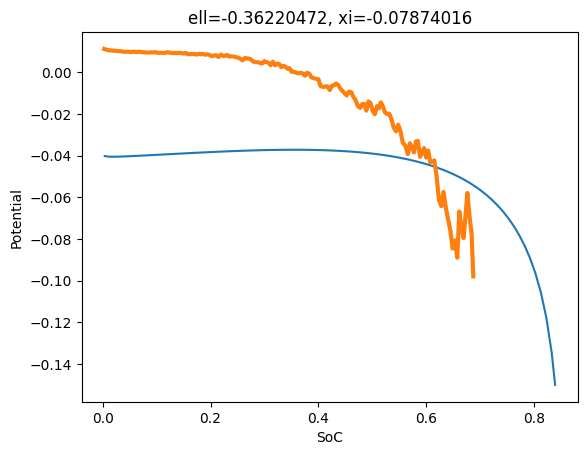

In [11]:
n = 0
data = data_dict[n]['data']
params = data_dict[n]['params']
coord = data_dict[n]['coord']
# print(f'ell={params[0]}', f'xi={params[1]}')
iso = gp.GalvanostaticProfile(xi=params[1], ell=params[0], g=-4)
iso.run()
iso.isotherm_plot()
plt.plot(data.SoC, data['E[V]'], lw=3)
plt.title(f'ell={params[0]}, xi={params[1]}')

# x = data.SoC.values
# y = data['E[V]'].values
# y = y[x>0.]
# x = x[x>0]

# x_ext, y_ext = extend_linearly_from_tail(x, y, -0.15, n_tail=3)

# plt.plot(x_ext, y_ext)

In [50]:
np.abs(iso.SOC.max()-x_ext.max())

0.019264605000607782

In [7]:
iso = gp.GalvanostaticProfile(xi=-.19, ell=-1.147, g=-4)
iso.run()

Text(0.5, 1.0, '$\\log(\\Xi)=-0.19$, $\\log(\\ell)=-1.147$')

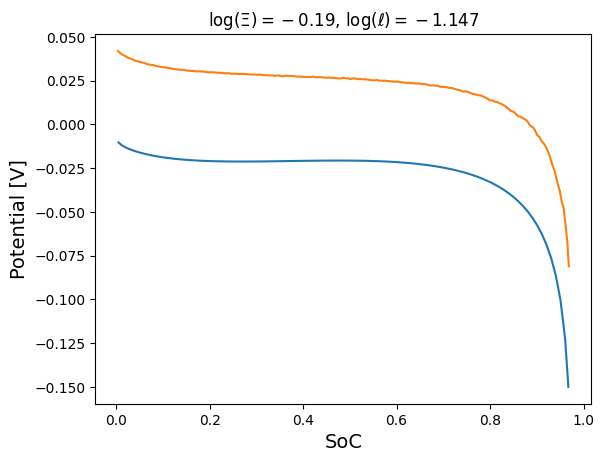

In [10]:
iso.isotherm_plot()
promedios_df = get_prom(8, -4)
plt.plot(promedios_df.SoC, promedios_df.Potential, label=f'{8} samples')
plt.xlabel('SoC', fontsize=14)
plt.ylabel('Potential [V]', fontsize=14)
plt.title(r'$\log(\Xi)=-0.19$, $\log(\ell)=-1.147$')

In [21]:
k0 = 1e-7
dcoeff = 1e-10
d = 5e-6
Crate = 15
gp.utils.logell(Crate, d, 1, dcoeff), gp.utils.logxi(Crate, dcoeff, k0, 1)

(-2.9822712330395684, -0.809894379144197)

In [24]:
Ly = 400e-8
1e-10 * 10 ** (-1.5) * 3600 / (Ly * Ly)

711.5124735378854